In [1]:
import pandas as pd
import numpy as np
import glob
from tqdm import tqdm 
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

Datasets merge (commented< as it takes long time to compute)

Link to download the initial files:

https://www.cepii.fr/DATA_DOWNLOAD/baci/data/BACI_HS17_V202501.zip


In [2]:
# Define the correct file pattern to match CSV files
file_pattern = "C:/Users/Popov/Documents/Studies/NES_studies/Python/Trade/Presentation/BACI_HS17_V202501/BACI_HS17_Y*.csv"

# Get all matching CSV files
file_list = glob.glob(file_pattern)

# Check if any files were found
if not file_list:
    print("No CSV files found. Check the file path and extension.")
else:
    # Create an empty list to store DataFrames
    df_list = []

    # Read and append each file to the list with tqdm progress bar
    for file in tqdm(file_list, desc="Loading CSV files", unit="file"):
        df = pd.read_csv(file, dtype={"t": int, "i": int, "j": int, "k": int, "v": float, "q": float})
        df_list.append(df)

    # Concatenate all DataFrames into one
    final_df = pd.concat(df_list, ignore_index=True)

    # Display dataset structure
    print(final_df.info())

Loading CSV files: 100%|██████████| 7/7 [00:29<00:00,  4.16s/file]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77553553 entries, 0 to 77553552
Data columns (total 6 columns):
 #   Column  Dtype  
---  ------  -----  
 0   t       int64  
 1   i       int64  
 2   j       int64  
 3   k       int64  
 4   v       float64
 5   q       float64
dtypes: float64(2), int64(4)
memory usage: 3.5 GB
None


In [3]:
# Rename the columns
final_df.rename(columns={
    't': 'year',
    'i': 'exporter',
    'j': 'importer',
    'k': 'product',
    'v': 'value',
    'q': 'quantity'
}, inplace=True)


Content:
Trade flows at the year - exporter - importer - product level.
Products in Harmonized System 6-digit nomenclature.
Values in thousand USD and quantities in metric tons.


Relevant HS Codes for Cut Flowers:

060311 – Fresh cut flowers and flower buds of roses

060312 – Fresh cut flowers and flower buds of carnations

060313 – Fresh cut flowers and flower buds of orchids

060314 – Fresh cut flowers and flower buds of chrysanthemums

060315 – Fresh cut flowers and flower buds of lilies

060319 – Fresh cut flowers and flower buds of other kinds

060390 – Other cut flowers and flower buds (dried, dyed, etc.)

In [4]:
# List of HS6 codes for cut flowers
cut_flowers_hs6 = [60311, 60312, 60313, 60314, 60315, 60319, 60390]  

# Filter the dataset to keep only rows with cut flower HS6 codes
final_df = final_df[final_df['product'].isin(cut_flowers_hs6)]

In [5]:
final_df.reset_index(drop=True, inplace=True)

# Display first few rows
final_df.head()

,year,exporter,importer,product,value,quantity
0,2017,8,251,60390,3.995,0.152
1,2017,8,380,60390,3.581,3.900
2,2017,8,398,60319,0.024,0.002
3,2017,8,499,60390,0.846,0.120
4,2017,8,616,60390,8.112,0.271


In [6]:
final_df.describe()

,year,exporter,importer,product,value,quantity
count,60807.000000,60807.000000,60807.000000,60807.000000,60807.000000,60109.000000
mean,2020.156742,441.385054,435.482609,60333.003223,1024.555797,175.438883
std,1.982910,236.641794,246.010584,32.351064,13203.242159,2253.478089
min,2017.000000,4.000000,4.000000,60311.000000,0.001000,0.001000
25%,2018.000000,218.000000,233.000000,60312.000000,0.494000,0.051000
50%,2020.000000,404.000000,422.000000,60319.000000,4.835000,0.580000
75%,2022.000000,688.000000,643.000000,60319.000000,56.147000,7.987000
max,2023.000000,894.000000,894.000000,60390.000000,915547.402000,158114.080000


In [7]:
# Compute descriptive statistics
desc_stats = final_df.describe()

# Convert to LaTeX format
latex_table = desc_stats.to_latex(float_format="%.1f", column_format="lcccccc", caption="Descriptive Statistics", label="tab:desc_stats")

# Save the table to a .tex file
with open("descriptive_statistics.tex", "w") as f:
    f.write(latex_table)

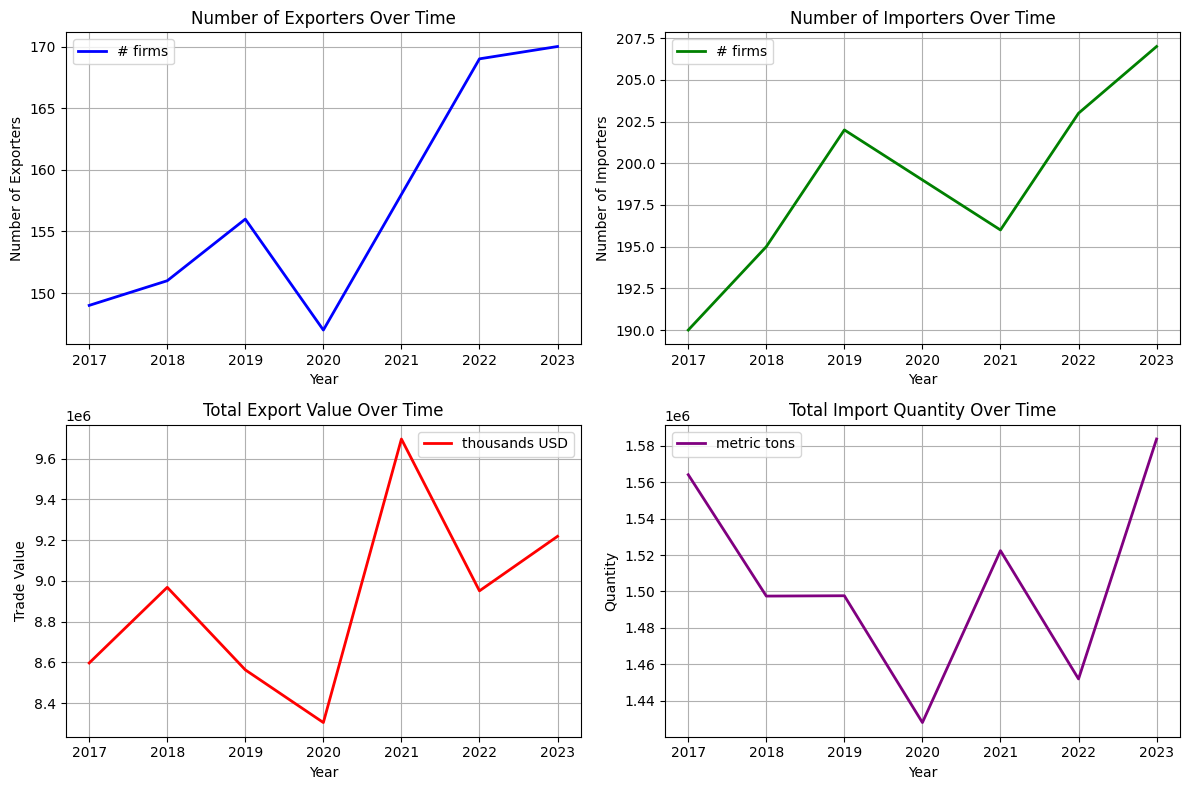

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Aggregate trade values over time for each variable
exporter_trend = final_df.groupby("year")["exporter"].nunique().astype(int)  # Unique exporters per year
importer_trend = final_df.groupby("year")["importer"].nunique().astype(int)  # Unique importers per year (integer format)
value_trend = final_df.groupby("year")["value"].sum()  # Convert to thousands USD
quantity_trend = final_df.groupby("year")["quantity"].sum()  # Metric tons

pdf_filename = "trade_dynamics.pdf"
with PdfPages(pdf_filename) as pdf:
    # Set up the figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Exporter Trend
    axes[0, 0].plot(exporter_trend.index, exporter_trend, label="# firms", color="b", linewidth=2)
    axes[0, 0].set_title("Number of Exporters Over Time")
    axes[0, 0].set_xlabel("Year")
    axes[0, 0].set_ylabel("Number of Exporters")
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Importer Trend
    axes[0, 1].plot(importer_trend.index, importer_trend, label="# firms", color="g", linewidth=2)
    axes[0, 1].set_title("Number of Importers Over Time")
    axes[0, 1].set_xlabel("Year")
    axes[0, 1].set_ylabel("Number of Importers")
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Export Value Trend
    axes[1, 0].plot(value_trend.index, value_trend, label="thousands USD", color="r", linewidth=2)
    axes[1, 0].set_title("Total Export Value Over Time")
    axes[1, 0].set_xlabel("Year")
    axes[1, 0].set_ylabel("Trade Value")
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Import Quantity Trend
    axes[1, 1].plot(quantity_trend.index, quantity_trend, label="metric tons", color="purple", linewidth=2)
    axes[1, 1].set_title("Total Import Quantity Over Time")
    axes[1, 1].set_xlabel("Year")
    axes[1, 1].set_ylabel("Quantity")
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    # Adjust layout and show the plot
    plt.tight_layout()
    
    
    # Save the figure to the PDF
    pdf.savefig(fig)
    
    plt.show()


In [9]:
# Save to a combined CSV file (optional)
final_df.to_csv("combined_trade_data.csv", index=False)

print("Combined dataset saved as 'combined_trade_data.csv'")

Combined dataset saved as 'combined_trade_data.csv'
